## PyTorch WorkFlow

Lets' explore an example of PyTorch end-to-end workflow.

Resources:

*Ground truth notebook* - https://github.com/mrdbourke/pytorch-deep-learning/blob/main/01_pytorch_workflow.ipynb

*Book version of a notebook* - https://www.learnpytorch.io/01_pytorch_workflow/

In [1]:
what_were_covering = {
    1: "data (prepare and load)",
    2: "build model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating a model (inference)",
    5: "saving and loading a model",
    6: "putting it all together"
}

what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [2]:
import torch 
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'1.11.0+cu102'

### 1. Data (preparing and loading)

Data can be almost anything in machine learning.

* Excel spreadsheet
* Images of any kind
* Videos (youtube has lots of data)
* Audio like songs or podcasts
* DNA Sequences
* Text

Machine learning is a game of two parts:

1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation.

To showcase this, let's create some *known* data using the linear regression formula.

We will use a linear regression formula to make a straight line with *known* **parameters**.

In [3]:
# Create known parameters
weight = 0.7
bias = 0.3

# Create 
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
len(X), len(y)

(50, 50)

### Splitting data into training and test sets (one of the most important concepts in machine learning in general)

Let's create a training and test set with our data.

In [5]:
# Create a train-test split
train_split = int(0.8 * len(X))
train_split

40

In [6]:
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [7]:
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [8]:
X_train

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800],
        [0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
        [0.6800],
        [0.7000],
        [0.7200],
        [0.7400],
        [0.7600],
        [0.7800]])

In [9]:
y_train

tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260],
        [0.4400],
        [0.4540],
        [0.4680],
        [0.4820],
        [0.4960],
        [0.5100],
        [0.5240],
        [0.5380],
        [0.5520],
        [0.5660],
        [0.5800],
        [0.5940],
        [0.6080],
        [0.6220],
        [0.6360],
        [0.6500],
        [0.6640],
        [0.6780],
        [0.6920],
        [0.7060],
        [0.7200],
        [0.7340],
        [0.7480],
        [0.7620],
        [0.7760],
        [0.7900],
        [0.8040],
        [0.8180],
        [0.8320],
        [0.8460]])

How might we better visualize our data?

This is where the data explorers' motto comes in!

"Visualize, visualize, visualize!"

In [10]:
def plot_predictions(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=None):
    '''
        Plots training data, test data and compares predictions.
    '''
    plt.figure(figsize=(8,6))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c='blue', s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="green", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions if they exist
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size":14})
    plt.show()

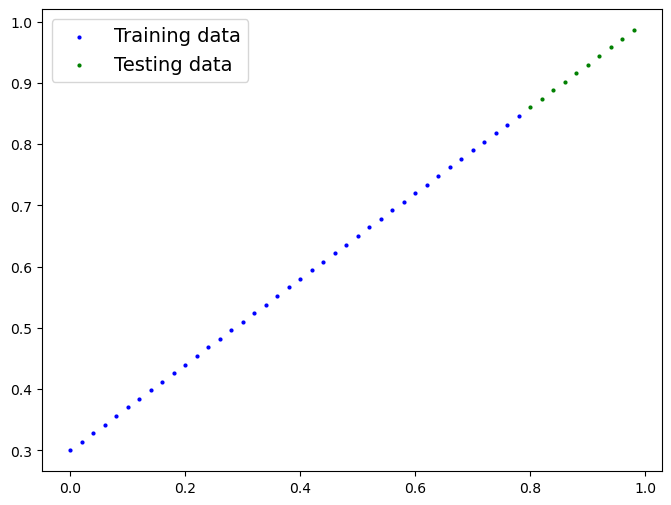

In [11]:
plot_predictions()

### 2. Build model

Our First PyTorch model!

This is very exciting. Let's do it!

Because we are going to be building classes throughout the course, I would recommend getting familiar with OOP in Python, to do so, you can use the following resource from Real Python: https://realpython.com/python-classes/

What our model does: 
* Start with random values (weight and bias)
* Look at training data and adjust the random values to better represent (or get closer) to the ideal values (the weight and bias values we used to create the data)

How does it do so?

Through two main algorithms:
1. Gradient descent - https://www.youtube.com/watch?v=IHZwWFHWa-w&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=2
2. Backpropagation - https://www.youtube.com/watch?v=Ilg3gGewQ5U&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=3

In [89]:
from torch import nn

# Create a linear regression model class
class LinearRegressionModel(nn.Module): # Almost everything in PyTorch inherits from nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- start with a random weight and try to adjust it to the ideal weight
                                               requires_grad=True, # <- can this parameter be updated via gradient descent?
                                               dtype=torch.float)) # <- PyTorch loves the datatypes torch.float32
        
        self.bias = nn.Parameter(torch.randn(1, # <- start with a random bias and try to adjust it to the ideal bias
                                            requires_grad=True, # <- can this parameter be updated via gradient descent?
                                            dtype=torch.float)) # <- PyTorch loves the datatype torch.float32

    # Forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:  # <- "x" is the input data
        return self.weights * x + self.bias # this is the linear regression formula

### PyTorch Model Building Essentials

* torch.nn - contains all of the building blocks for computatitional graphs (a neural network can be considered a computational graph)
* torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us
* torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward()
* torch.optim - this is where the optimizers in PyTorch live, they will help with gradient descent
* def forward() - all nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation

See more of these essential modules via the PyTorch cheatsheet - https://pytorch-cn.com/tutorials/beginner/ptcheat.html

### Checking the contents of our PyTorch model

Now we have created a model, let's see what's inside....

So we can check our model parameters or what's inside our model using `.parameters()`.

In [90]:
# torch.manual_seed(42)
# torch.randn(1)

In [112]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [113]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [114]:
weight, bias

(0.7, 0.3)

#### Making predictions using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts  `y_test` based on `X_test`. 

When we pass data through our model, it's going to run it through the `forward()` method.

In [115]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [116]:
# Make predictions with the model
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [117]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

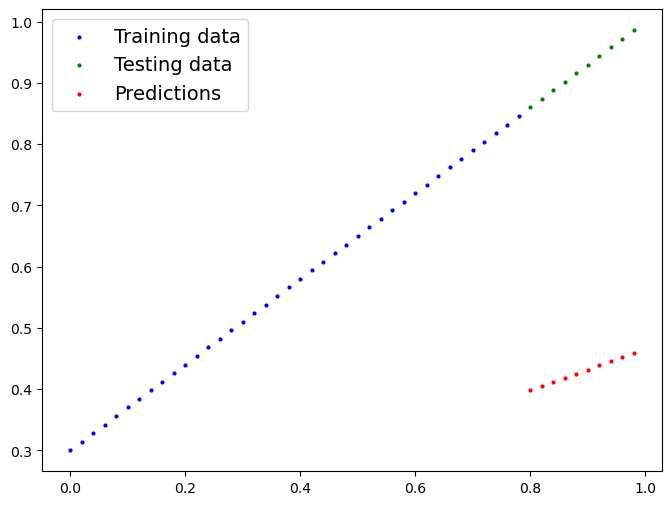

In [118]:
plot_predictions(predictions=y_preds)

In [119]:
y_preds = model_0(X_test)

In [120]:
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [121]:
# You can also do something similar with torch.no_grad(), however, torch.inference_mode() is preferred
with torch.no_grad():
    y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

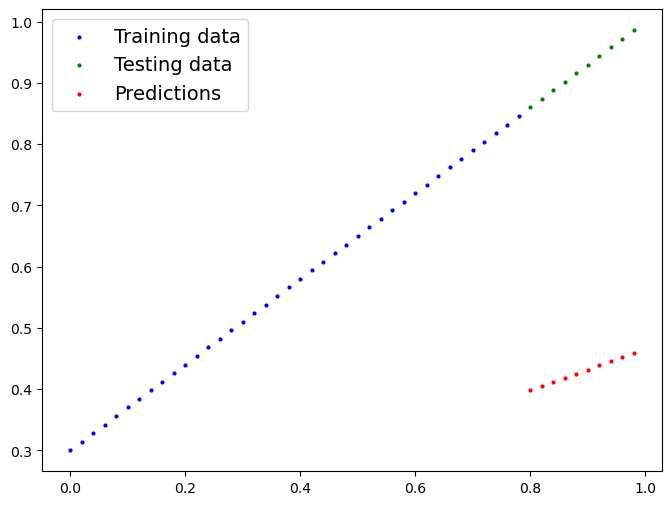

In [122]:
plot_predictions(predictions=y_preds)

### 3. Train model

The whole idea of training is for a model to move from some *unknown* parameters (these may be random) to some *known* parameters.

Or in other words, from a poor representation of the data to a better representation of the data.

One way to measure how wrong your model's predictions are is to use a loss function.

* Note: Loss function may also be called cost function or criterion in different areas. For our case, we are going to refer to it as a loss function.

Things we need to train:

* **Loss function:** A function to measure how wrong your model predictions are to the ideal outputs, lower is better - https://docs.pytorch.org/docs/2.12/nn.html#loss-functions
* **Optimizer:** Takes into account the loss of a model and adjusts the model's parameters (e.g. weight and bias in our case) to improve the loss function - https://docs.pytorch.org/docs/2.12/optim.html#torch.optim.Optimizer
  * Inside the optimizer you'll often have to set two parameters:
      - `params` - the model parameters you'd like to optimize, for example `params=model_0.parameters()`
      - `lr`(learning rate) - the learning rate is a hyperparameter that defines how big/small the optimizer changes the parameters with each step (a small `lr` results in small changes, a large `lr` results in large changes).

And specifically for PyTorch we need:

* A training loop
* A testing loop

In [123]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [124]:
# Check out our model's parameters (a parameter is a value that the model sets itself)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [125]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(),
                           lr=0.01) # lr = learning rate = most important hyperparameter you can set

**Q:** Which loss function and optimizer should I use?

**A:** This will be problem specific. But with experience, you will get an idea of what works and what does not with your particular problem set.

For example, for a regression problem (like ours), a loss function of `nn.L1Loss()` and an optimizer like `torch.optim.SGD()` will suffice.

But, for a classification problem like classifying whether a photo is of a dog or a cat, you will likely want to use a loss function of `nn.BCELoss()` (binary cross entropy loss)

### Building a training loop (and a testing loop) in PyTorch 

A couple of things we need in a training loop:

0. Loop through the data
1. Forward pass (this involves data moving through our model's `forward` functions) to make predictions on data - also called forward propagation.
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss Backward - move backwards through the network to calculate the gradient of each of the parameters of our model with respect to the loss (**backpropagation**)
5. Optimizer step - use the optimizer to adjust to our model's parameters to try and improve the loss (**gradient descent**)

In [126]:
with torch.inference_mode():
    list(model_0.parameters())

In [127]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [128]:
with torch.no_grad:
    list(model_0.parameters())

AttributeError: __enter__

In [133]:
torch.manual_seed(42)
# An epoch is one loop through the data ... (this is a hyper parameter because we have set it ourselves)
epochs = 100

### Training
# 0. Loop through the data
for epoch in range(epochs):
    # Set the model to training mode
    model_0.train() # train model in PyTorch sets all parameters that require gradients to require gradients

    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y_train)
    print("Loss: {:.3f}".format(loss))

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backprogagation on the loss with respect to the parameters of the model
    loss.backward()

    # 5. Step the optimizer (perform gradient descent)
    optimizer.step() # by default how the optimizer changes accumulate through the loop... so we have to zero them above in step 3 for the next iteration of the loop

    ### Testing
    model_0.eval() # turns off different settings in the model not needed for evaluation/testing (dropout/batch norm layers)
    with torch.inference_mode(): # turns off gradient tracking and a couple more things behind the scenes
    #with torch.no_grad(): you may also see torch.no_grad()in older pytorch code
        # 1. Do the Forward pass
        test_pred = model_0(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    # Print out what happened
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Test: {loss} | Test Loss: {test_loss}")       
        # Print out model state_dict()
        print(f"Weight: {model_0.state_dict()['weights'][0]:.3f} Bias: {model_0.state_dict()['bias'][0]:.3f}")

Loss: 0.024
Epoch: 0 | Test: 0.024458957836031914 | Test Loss: 0.05646304413676262
Weight: 0.580 Bias: 0.350
Loss: 0.024
Loss: 0.024
Loss: 0.023
Loss: 0.023
Loss: 0.023
Loss: 0.022
Loss: 0.022
Loss: 0.022
Loss: 0.021
Loss: 0.021
Epoch: 10 | Test: 0.021020207554101944 | Test Loss: 0.04819049686193466
Weight: 0.597 Bias: 0.343
Loss: 0.021
Loss: 0.020
Loss: 0.020
Loss: 0.020
Loss: 0.019
Loss: 0.019
Loss: 0.019
Loss: 0.018
Loss: 0.018
Loss: 0.018
Epoch: 20 | Test: 0.01758546568453312 | Test Loss: 0.04060482233762741
Weight: 0.614 Bias: 0.336
Loss: 0.017
Loss: 0.017
Loss: 0.017
Loss: 0.016
Loss: 0.016
Loss: 0.016
Loss: 0.015
Loss: 0.015
Loss: 0.014
Loss: 0.014
Epoch: 30 | Test: 0.014155393466353416 | Test Loss: 0.03233227878808975
Weight: 0.631 Bias: 0.329
Loss: 0.014
Loss: 0.013
Loss: 0.013
Loss: 0.013
Loss: 0.012
Loss: 0.012
Loss: 0.012
Loss: 0.011
Loss: 0.011
Loss: 0.011
Epoch: 40 | Test: 0.010716589167714119 | Test Loss: 0.024059748277068138
Weight: 0.648 Bias: 0.322
Loss: 0.010
Loss: 0

In [137]:
weight, bias # original values

(0.7, 0.3)

In [134]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

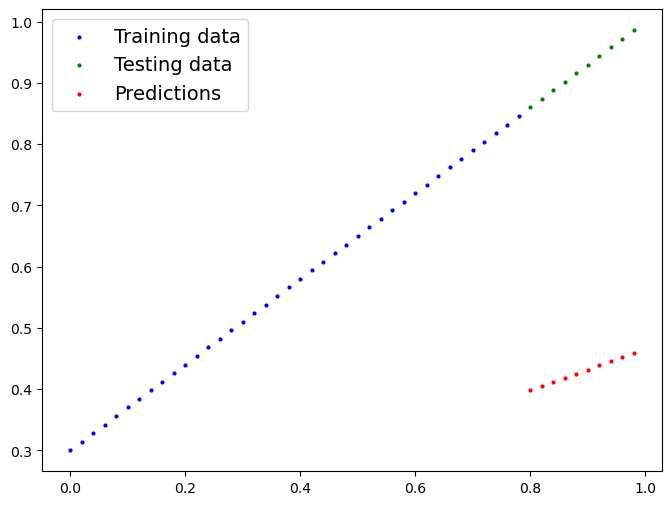

In [135]:
plot_predictions(predictions=y_preds)

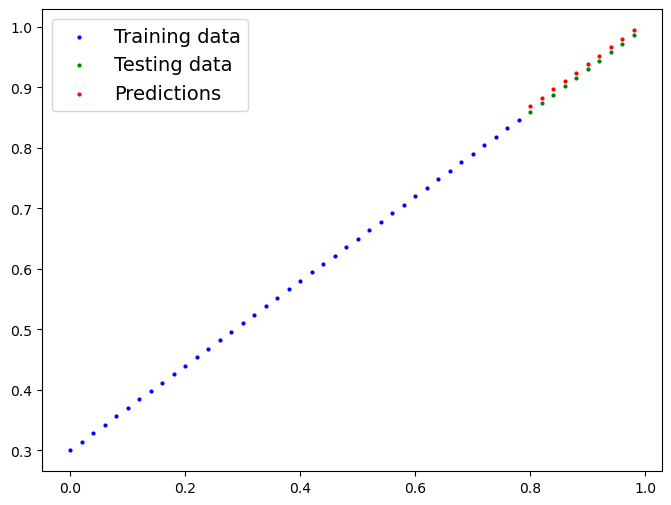

In [136]:
plot_predictions(predictions=y_preds_new)